# Revenue & Growth Analysis


**Dataset:** Olist Brazilian E-Commerce (2016–2018),  around 100k orders across 
multiple product categories and payment methods.

In [11]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()


DATA_PATH = r"C:\Users\UCWAcc\projects\ecommerce-analytics\data"

con.execute(f"""
    CREATE TABLE customers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_customers_dataset.csv');
    CREATE TABLE orders AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_orders_dataset.csv');
    CREATE TABLE order_items AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_items_dataset.csv');
    CREATE TABLE products AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_products_dataset.csv');
    CREATE TABLE sellers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_sellers_dataset.csv');
    CREATE TABLE payments AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_payments_dataset.csv');
    CREATE TABLE reviews AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_reviews_dataset.csv');
    CREATE TABLE geolocation AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_geolocation_dataset.csv');
    CREATE TABLE category_translation AS SELECT * FROM read_csv_auto('{DATA_PATH}/product_category_name_translation.csv');
""")

def sql(query):
    return con.execute(query).fetchdf()

## How has monthly revenue trended?

Starting with the big picture,  total revenue and order volume by month. 
Here only counting delivered orders since canceled, not shipped etc ones don't represent 
actual money getting encashed in the bank.

In [13]:
monthly = sql("""
    SELECT DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
           COUNT(DISTINCT o.order_id) AS total_orders,
           ROUND(SUM(oi.price), 2) AS revenue,
           ROUND(SUM(oi.freight_value), 2) AS freight_collected
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY month
    ORDER BY month
""")
monthly

,month,total_orders,revenue,freight_collected
0,2016-09-01,1,134.97,8.49
1,2016-10-01,265,40325.11,6165.55
2,2016-12-01,1,10.90,8.72
3,2017-01-01,750,111798.36,15684.01
4,2017-02-01,1653,234223.40,37015.92
5,2017-03-01,2546,359198.85,55132.10
6,2017-04-01,2303,340669.68,50142.72
7,2017-05-01,3546,489338.25,77513.15
8,2017-06-01,3135,421923.37,68127.00
9,2017-07-01,3872,481604.52,84694.56


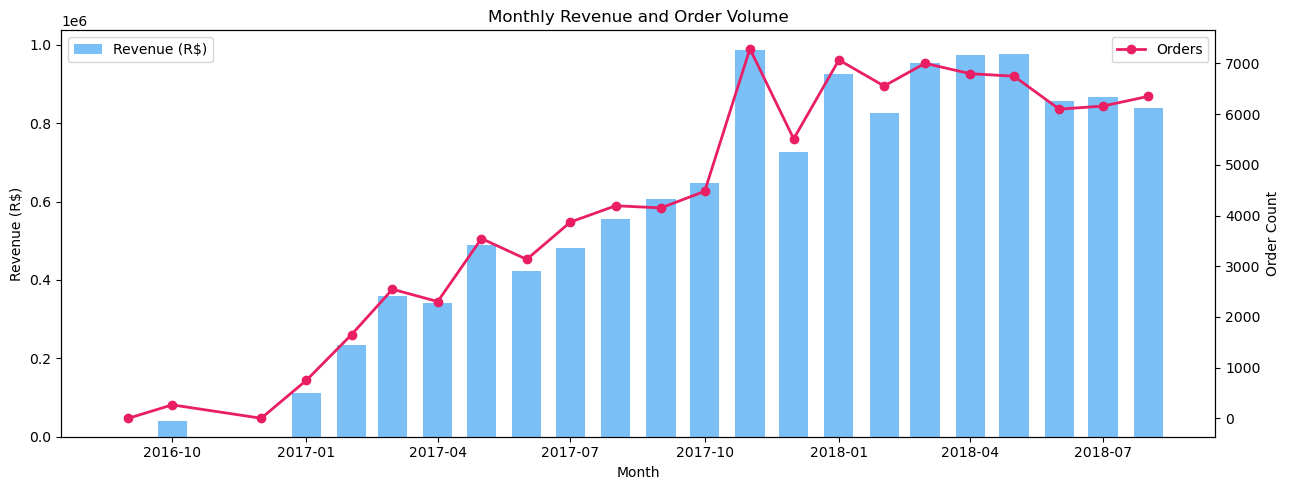

In [14]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(monthly['month'], monthly['revenue'], width=20, alpha=0.6, label='Revenue (R$)', color='#2196F3')
ax1.set_ylabel('Revenue (R$)')
ax1.set_xlabel('Month')

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['total_orders'], color='#E91E63', marker='o', linewidth=2, label='Orders')
ax2.set_ylabel('Order Count')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Monthly Revenue and Order Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Month-over-month growth rate

Raw revenue numbers are useful but growth rate tells a sharper story. 

Using `LAG()` function to compare each month against the one before it.

In [16]:
mom = sql("""
    WITH monthly_rev AS (
        SELECT DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
               ROUND(SUM(oi.price), 2) AS revenue
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY month
    )
    SELECT month,
           revenue,
           LAG(revenue, 1) OVER (ORDER BY month) AS prev_month,
           ROUND(
               (revenue - LAG(revenue, 1) OVER (ORDER BY month))
               / LAG(revenue, 1) OVER (ORDER BY month) * 100,
           1) AS growth_pct
    FROM monthly_rev
    ORDER BY month
""")
mom

,month,revenue,prev_month,growth_pct
0,2016-09-01,134.97,NaN,NaN
1,2016-10-01,40325.11,134.97,29777.1
2,2016-12-01,10.90,40325.11,-100.0
3,2017-01-01,111798.36,10.90,1025573.0
4,2017-02-01,234223.40,111798.36,109.5
5,2017-03-01,359198.85,234223.40,53.4
6,2017-04-01,340669.68,359198.85,-5.2
7,2017-05-01,489338.25,340669.68,43.6
8,2017-06-01,421923.37,489338.25,-13.8
9,2017-07-01,481604.52,421923.37,14.1


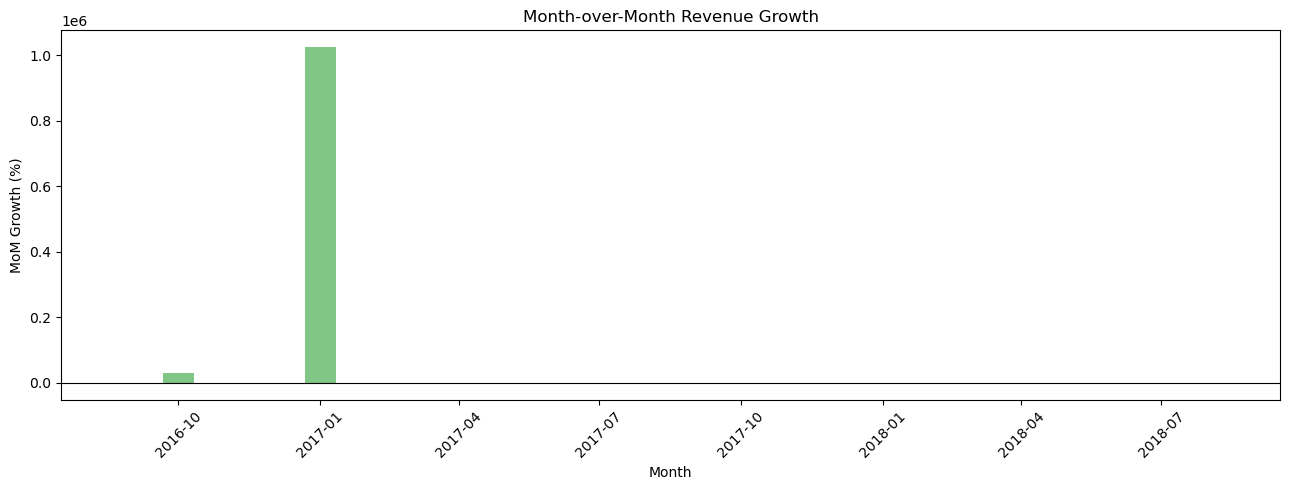

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#4CAF50' if x >= 0 else '#F44336' for x in mom['growth_pct'].fillna(0)]
ax.bar(mom['month'], mom['growth_pct'].fillna(0), width=20, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('MoM Growth (%)')
ax.set_xlabel('Month')
plt.title('Month-over-Month Revenue Growth')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Where does the revenue come from?

Not all categories pull the same weight. Some drive volume at lower prices, 
others bring in fewer orders but at higher ticket sizes. Both patterns are 
worth understanding.

In [19]:
categories = sql("""
    SELECT COALESCE(ct.product_category_name_english, p.product_category_name) AS category,
           COUNT(*) AS items_sold,
           ROUND(SUM(oi.price), 2) AS total_revenue,
           ROUND(AVG(oi.price), 2) AS avg_price,
           COUNT(DISTINCT o.order_id) AS unique_orders
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY COALESCE(ct.product_category_name_english, p.product_category_name)
    ORDER BY total_revenue DESC
    LIMIT 15
""")
categories

,category,items_sold,total_revenue,avg_price,unique_orders
0,health_beauty,9465,1233131.72,130.28,8647
1,watches_gifts,5859,1166176.98,199.04,5495
2,bed_bath_table,10953,1023434.76,93.44,9272
3,sports_leisure,8431,954852.55,113.25,7530
4,computers_accessories,7644,888724.61,116.26,6530
5,furniture_decor,8160,711927.69,87.25,6307
6,housewares,6795,615628.69,90.60,5743
7,cool_stuff,3718,610204.10,164.12,3559
8,auto,4140,578966.65,139.85,3810
9,toys,4030,471286.48,116.94,3804


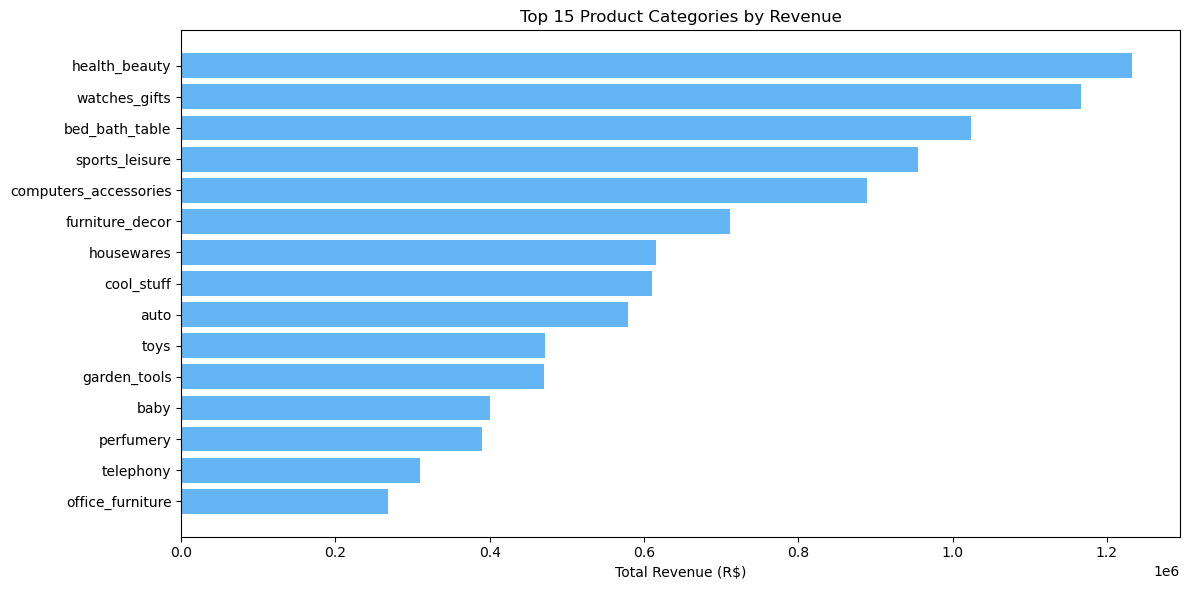

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(categories['category'][::-1], categories['total_revenue'][::-1], color='#2196F3', alpha=0.7)
ax.set_xlabel('Total Revenue (R$)')
ax.set_title('Top 15 Product Categories by Revenue')
plt.tight_layout()
plt.show()

## Revenue concentration : the Pareto question

The 80/20 rule shows up almost everywhere in day to day activities, be it preparation for an interview or a classic business problem. Here the question is whether 
a small handful of categories carry the entire business, or if revenue is 
spread out. Heavy concentration = risk if that category slumps, but also 
a clear signal of where to invest.

In [22]:
pareto = sql("""
    WITH cat_rev AS (
        SELECT COALESCE(ct.product_category_name_english, p.product_category_name) AS category,
               ROUND(SUM(oi.price), 2) AS revenue
        FROM order_items oi
        JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY COALESCE(ct.product_category_name_english, p.product_category_name)
    ),
    ranked AS (
        SELECT category,
               revenue,
               SUM(revenue) OVER (ORDER BY revenue DESC) AS running_total,
               SUM(revenue) OVER () AS grand_total,
               ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rank,
               COUNT(*) OVER () AS num_categories
        FROM cat_rev
    )
    SELECT rank,
           category,
           revenue,
           ROUND(running_total / grand_total * 100, 1) AS cumulative_pct,
           ROUND(rank * 100.0 / num_categories, 1) AS pct_of_categories
    FROM ranked
    ORDER BY rank
""")
pareto

,rank,category,revenue,cumulative_pct,pct_of_categories
0,1,health_beauty,1233131.72,9.3,1.4
1,2,watches_gifts,1166176.98,18.1,2.7
2,3,bed_bath_table,1023434.76,25.9,4.1
3,4,sports_leisure,954852.55,33.1,5.4
4,5,computers_accessories,888724.61,39.8,6.8
...,...,...,...,...,...
69,70,flowers,1110.04,100.0,94.6
70,71,home_comfort_2,760.27,100.0,95.9
71,72,cds_dvds_musicals,730.00,100.0,97.3
72,73,fashion_childrens_clothes,519.95,100.0,98.6


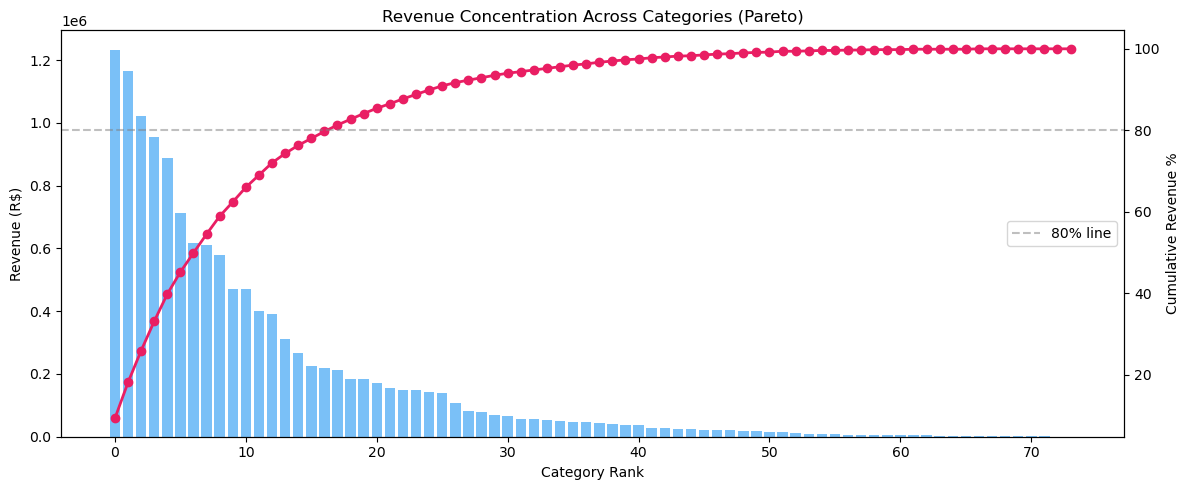

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(pareto)), pareto['revenue'], alpha=0.6, color='#2196F3')
ax2 = ax.twinx()
ax2.plot(range(len(pareto)), pareto['cumulative_pct'], color='#E91E63', marker='o', linewidth=2)
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% line')
ax2.set_ylabel('Cumulative Revenue %')
ax.set_ylabel('Revenue (R$)')
ax.set_xlabel('Category Rank')
ax2.legend(loc='center right')
plt.title('Revenue Concentration Across Categories (Pareto)')
plt.tight_layout()
plt.show()

## Payment methods

How customers pay matters beyond just "did they pay." Credit card installments 
are huge in Brazil!- a single 500 dollar purchase might get split into 10 monthly 
payments of 50 dollars. That's real revenue on the books, but the cash doesn't 
arrive all at once. Any financial planning has to account for this.

In [25]:
payments = sql("""
    SELECT payment_type,
           COUNT(*) AS transactions,
           ROUND(SUM(payment_value), 2) AS total_value,
           ROUND(AVG(payment_value), 2) AS avg_value,
           ROUND(AVG(payment_installments), 1) AS avg_installments,
           MAX(payment_installments) AS max_installments
    FROM payments
    GROUP BY payment_type
    ORDER BY total_value DESC
""")
payments

,payment_type,transactions,total_value,avg_value,avg_installments,max_installments
0,credit_card,76795,12542084.19,163.32,3.5,24
1,boleto,19784,2869361.27,145.03,1.0,1
2,voucher,5775,379436.87,65.70,1.0,1
3,debit_card,1529,217989.79,142.57,1.0,1
4,not_defined,3,0.00,0.00,1.0,1


## When do people buy?

Quick look at day-of-week patterns. Useful for deciding when to run 
promotions or allocate customer support capacity.

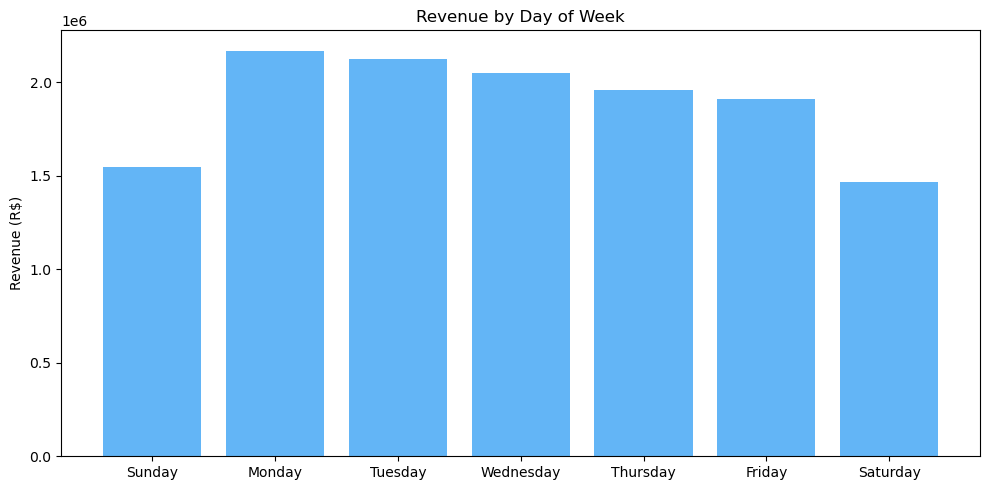

In [27]:
dow = sql("""
    SELECT DAYNAME(o.order_purchase_timestamp) AS day_of_week,
           DAYOFWEEK(o.order_purchase_timestamp) AS day_num,
           COUNT(DISTINCT o.order_id) AS orders,
           ROUND(SUM(oi.price), 2) AS revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY day_of_week, day_num
    ORDER BY day_num
""")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow['day_of_week'], dow['revenue'], color='#2196F3', alpha=0.7)
ax.set_ylabel('Revenue (R$)')
ax.set_title('Revenue by Day of Week')
plt.tight_layout()
plt.show()

## Takeaways

**Strong growth, then plateau.** Revenue scaled from 40k dollars per month in late 2016 to nearly 1 million dollars  by mid-2018 - roughly 25x growth in under two years. The November 2017 spike (+52% MoM) is almost certainly a Black Friday effect. Growth flattened in the final months, and August 2018's dip could be real or could be incomplete data at the dataset cutoff — something you'd verify before reporting externally.

**Moderate category concentration.** 18 out of 74 categories (24%) generate 80% of revenue. That's not extreme - the business isn't dangerously dependent on any single category. Health & beauty (beleza_saude) leads at R$1.2M, followed by watches/gifts and bed/bath/table. Growth strategy should probably focus on platform-level improvements (logistics, search, seller quality) rather than betting on one category.

**Credit cards with installments dominate.** 74% of all transactions are credit card, averaging 3.5 installments. Boleto (bank slip) is a distant second. This installment culture means a large chunk of recognized revenue hasn't actually been collected yet in cash — critical for any financial planning or cash flow forecasting.

**Weekday shopping bias.** Most purchasing happens Monday through Friday. Weekend promotional campaigns might be under-explored, or it might just reflect this customer base's browsing habits. Worth A/B testing a targeted weekend push.
